In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
customers = pd.read_csv("../data/raw/customers.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")

print("Datasets loaded successfully.")

print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)

Datasets loaded successfully.
Customers: (1000, 6)
Restaurants: (100, 6)
Orders: (5000, 10)
Deliveries: (5000, 7)


In [4]:
orders.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,number_of_items,weather,traffic_condition,order_status,preparation_time_minutes
0,ORD_00001,CUST_0785,REST_025,2026-05-10 00:04:01,100.00,1,Cloudy,Medium,Delivered,28.0
1,ORD_00002,CUST_0894,REST_066,2026-04-30 05:33:18,396.77,1,Cloudy,Low,Delivered,30.0
2,ORD_00003,CUST_0776,REST_100,2026-02-03 10:44:48,197.80,5,Clear,Low,Delivered,38.0
3,ORD_00004,CUST_0569,REST_018,2026-05-17 07:27:57,145.79,5,Rain,High,Delivered,32.0
4,ORD_00005,CUST_0298,REST_005,2026-05-21 01:33:11,147.25,2,Rain,Low,Delivered,39.0


In [5]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'number_of_items', 'weather', 'traffic_condition', 'order_status', 'preparation_time_minutes']


In [6]:
restaurants.head()

,restaurant_id,restaurant_name,category,city,rating,avg_preparation_time
0,REST_001,Restaurant_001,Pizza,Hyderabad,4.8,12
1,REST_002,Restaurant_002,North Indian,Pune,4.2,37
2,REST_003,Restaurant_003,South Indian,Chennai,4.4,12
3,REST_004,Restaurant_004,Healthy,Hyderabad,3.7,14
4,REST_005,Restaurant_005,Chinese,Chennai,4.4,36


In [11]:
deliveries.head()

,delivery_id,order_id,driver_id,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,tip_amount
0,DEL_00001,ORD_00001,DRV_0292,7.57,28.0,77.8,10.68
1,DEL_00002,ORD_00002,DRV_0419,8.61,30.0,68.3,47.62
2,DEL_00003,ORD_00003,DRV_0424,19.09,38.0,117.3,22.97
3,DEL_00004,ORD_00004,DRV_0407,5.79,32.0,89.5,26.44
4,DEL_00005,ORD_00005,DRV_0201,3.90,39.0,68.2,17.81


In [12]:
print(deliveries.columns.tolist())

['delivery_id', 'order_id', 'driver_id', 'delivery_distance_km', 'preparation_time_minutes', 'delivery_time_minutes', 'tip_amount']


In [7]:
print(restaurants.columns.tolist())

['restaurant_id', 'restaurant_name', 'category', 'city', 'rating', 'avg_preparation_time']


In [8]:
customers.head()

,customer_id,age,gender,city,signup_date,membership_type
0,CUST_0001,56,Male,Pune,2025-07-08 03:38:37,Regular
1,CUST_0002,46,Female,Chennai,2025-08-07 23:03:12,Regular
2,CUST_0003,32,Male,Delhi,2025-10-04 13:45:34,Regular
3,CUST_0004,60,Female,Pune,2025-11-01 05:35:20,Regular
4,CUST_0005,25,Female,Mumbai,2025-06-02 03:42:14,Regular


In [10]:
print(customers.columns.tolist())

['customer_id', 'age', 'gender', 'city', 'signup_date', 'membership_type']


In [13]:
df = orders.merge(
    deliveries,
    on="order_id",
    how="inner",
    suffixes=("_order", "_delivery")
)

print("Orders + Deliveries merged successfully.")
print("Shape:", df.shape)

Orders + Deliveries merged successfully.
Shape: (5000, 16)


In [14]:
df = df.merge(
    restaurants[
        [
            "restaurant_id",
            "category",
            "rating"
        ]
    ],
    on="restaurant_id",
    how="left"
)

print("Restaurant information added successfully.")
print("Shape:", df.shape)

Restaurant information added successfully.
Shape: (5000, 18)


In [15]:
df.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,number_of_items,weather,traffic_condition,order_status,preparation_time_minutes_order,delivery_id,driver_id,delivery_distance_km,preparation_time_minutes_delivery,delivery_time_minutes,tip_amount,category,rating
0,ORD_00001,CUST_0785,REST_025,2026-05-10 00:04:01,100.00,1,Cloudy,Medium,Delivered,28.0,DEL_00001,DRV_0292,7.57,28.0,77.8,10.68,South Indian,4.0
1,ORD_00002,CUST_0894,REST_066,2026-04-30 05:33:18,396.77,1,Cloudy,Low,Delivered,30.0,DEL_00002,DRV_0419,8.61,30.0,68.3,47.62,North Indian,3.5
2,ORD_00003,CUST_0776,REST_100,2026-02-03 10:44:48,197.80,5,Clear,Low,Delivered,38.0,DEL_00003,DRV_0424,19.09,38.0,117.3,22.97,Pizza,3.9
3,ORD_00004,CUST_0569,REST_018,2026-05-17 07:27:57,145.79,5,Rain,High,Delivered,32.0,DEL_00004,DRV_0407,5.79,32.0,89.5,26.44,Pizza,3.6
4,ORD_00005,CUST_0298,REST_005,2026-05-21 01:33:11,147.25,2,Rain,Low,Delivered,39.0,DEL_00005,DRV_0201,3.90,39.0,68.2,17.81,Chinese,4.4


In [16]:
print(df.columns.tolist())

['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'number_of_items', 'weather', 'traffic_condition', 'order_status', 'preparation_time_minutes_order', 'delivery_id', 'driver_id', 'delivery_distance_km', 'preparation_time_minutes_delivery', 'delivery_time_minutes', 'tip_amount', 'category', 'rating']


In [17]:
df.isnull().sum()

order_id                             0
customer_id                          0
restaurant_id                        0
order_timestamp                      0
order_amount                         0
number_of_items                      0
weather                              0
traffic_condition                    0
order_status                         0
preparation_time_minutes_order       0
delivery_id                          0
driver_id                            0
delivery_distance_km                 0
preparation_time_minutes_delivery    0
delivery_time_minutes                0
tip_amount                           0
category                             0
rating                               0
dtype: int64

In [18]:
print(df["delivery_time_minutes"].describe())

count    5000.000000
mean       63.283980
std        17.463145
min        18.800000
25%        51.100000
50%        62.200000
75%        73.800000
max       137.600000
Name: delivery_time_minutes, dtype: float64


In [19]:
print(
    "Duplicate order IDs:",
    df["order_id"].duplicated().sum()
)

Duplicate order IDs: 0


In [20]:
print(
    df["order_status"].value_counts()
)

order_status
Delivered    4665
Cancelled     335
Name: count, dtype: int64


In [21]:
df = df[
    df["order_status"] == "Delivered"
].copy()

print("Delivered orders:", len(df))
print("Cancelled orders removed:", 5000 - len(df))

Delivered orders: 4665
Cancelled orders removed: 335


In [22]:
print(df["delivery_time_minutes"].describe())

count    4665.000000
mean       63.241801
std        17.409925
min        19.400000
25%        51.100000
50%        62.200000
75%        73.700000
max       137.600000
Name: delivery_time_minutes, dtype: float64


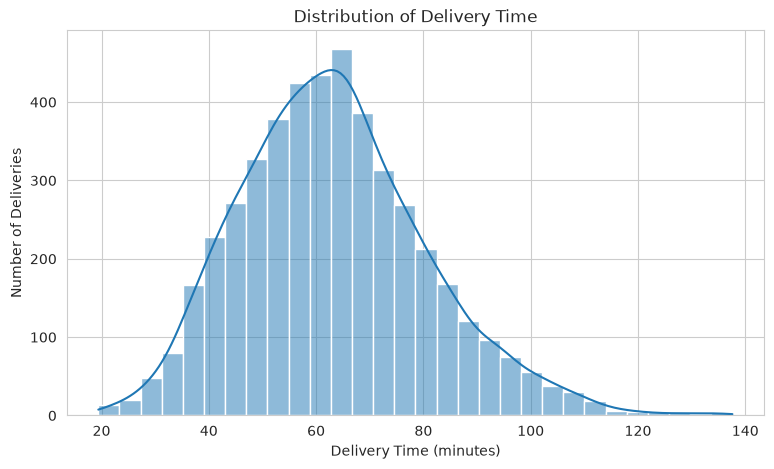

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="delivery_time_minutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")

plt.show()

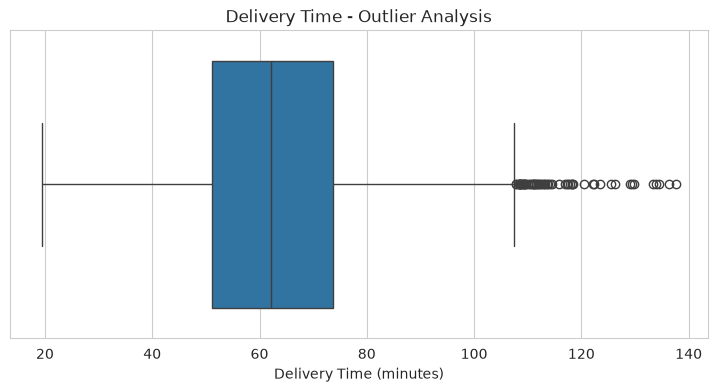

In [24]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    x=df["delivery_time_minutes"]
)

plt.title("Delivery Time - Outlier Analysis")
plt.xlabel("Delivery Time (minutes)")

plt.show()

In [25]:
numeric_columns = [
    "order_amount",
    "number_of_items",
    "delivery_distance_km",
    "preparation_time_minutes_order",
    "preparation_time_minutes_delivery",
    "rating",
    "delivery_time_minutes",
    "tip_amount"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,order_amount,number_of_items,delivery_distance_km,preparation_time_minutes_order,preparation_time_minutes_delivery,rating,delivery_time_minutes,tip_amount
order_amount,1.000000,0.002666,0.020386,0.010530,0.010530,-0.007845,0.031670,0.701449
number_of_items,0.002666,1.000000,-0.012999,0.026623,0.026623,-0.012302,-0.001550,0.007531
delivery_distance_km,0.020386,-0.012999,1.000000,0.007368,0.007368,-0.015876,0.719418,0.018288
preparation_time_minutes_order,0.010530,0.026623,0.007368,1.000000,1.000000,-0.011418,0.370497,0.010561
preparation_time_minutes_delivery,0.010530,0.026623,0.007368,1.000000,1.000000,-0.011418,0.370497,0.010561
rating,-0.007845,-0.012302,-0.015876,-0.011418,-0.011418,1.000000,-0.023058,-0.012321
delivery_time_minutes,0.031670,-0.001550,0.719418,0.370497,0.370497,-0.023058,1.000000,0.031250
tip_amount,0.701449,0.007531,0.018288,0.010561,0.010561,-0.012321,0.031250,1.000000


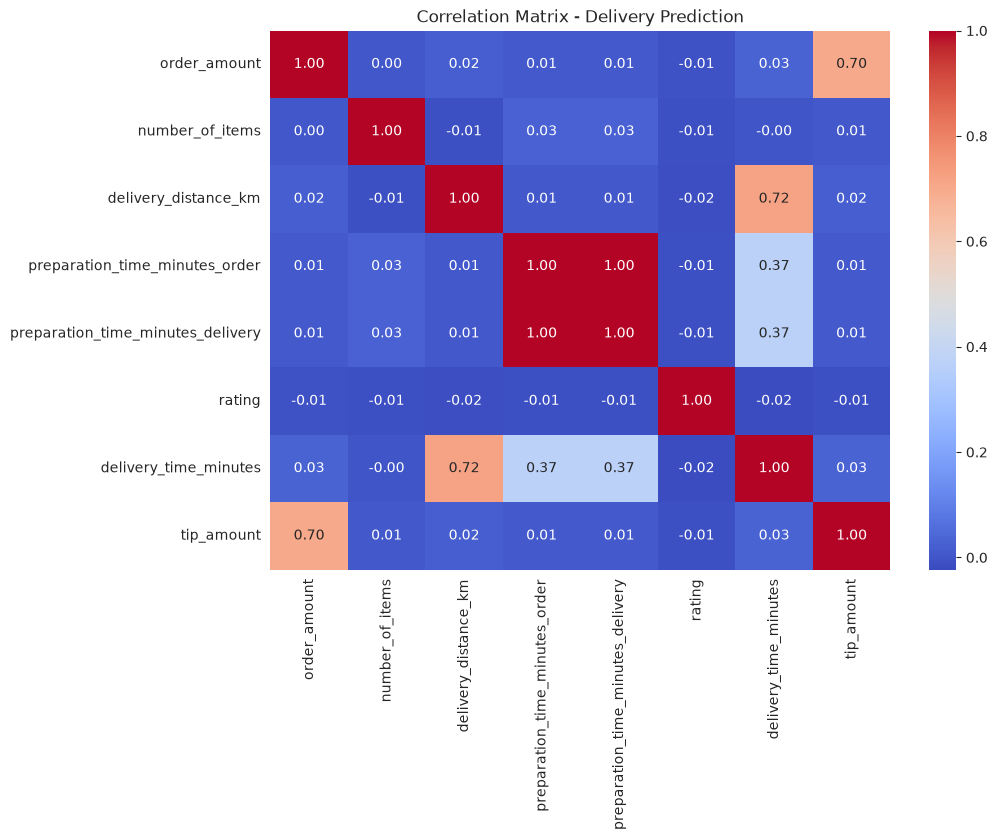

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Delivery Prediction")

plt.show()

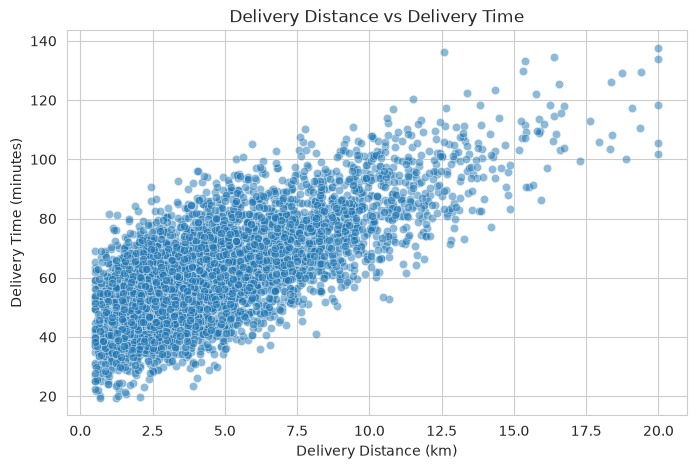

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="delivery_distance_km",
    y="delivery_time_minutes",
    alpha=0.5
)

plt.title("Delivery Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

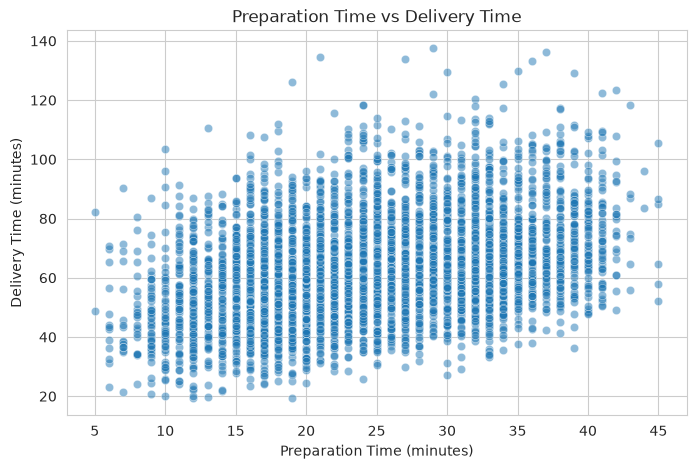

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="preparation_time_minutes_delivery",
    y="delivery_time_minutes",
    alpha=0.5
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

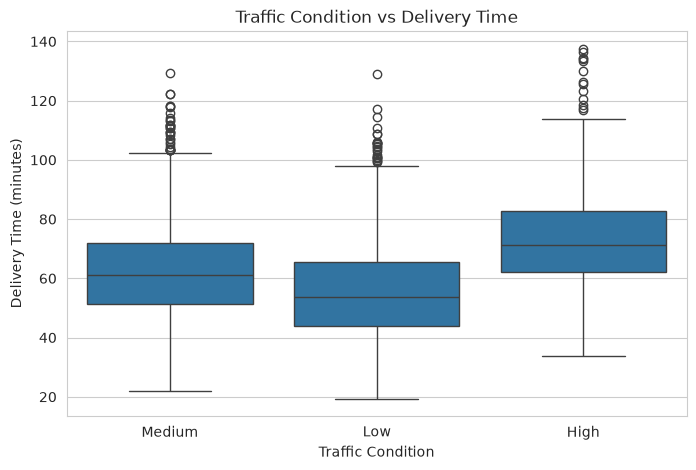

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="traffic_condition",
    y="delivery_time_minutes"
)

plt.title("Traffic Condition vs Delivery Time")
plt.xlabel("Traffic Condition")
plt.ylabel("Delivery Time (minutes)")

plt.show()

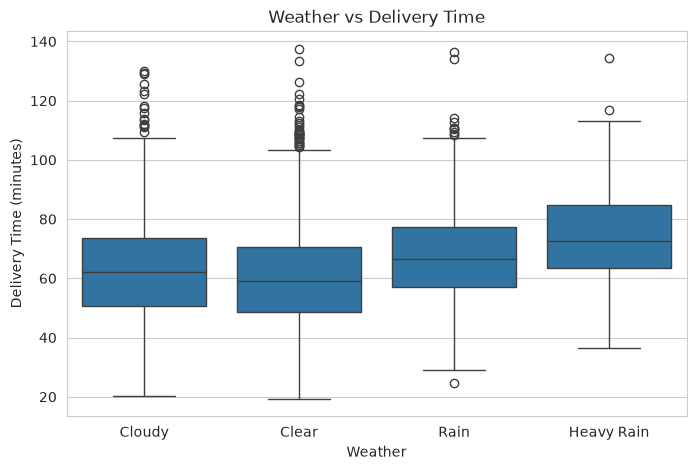

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="weather",
    y="delivery_time_minutes"
)

plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")

plt.show()

In [31]:
df["order_timestamp"] = pd.to_datetime(
    df["order_timestamp"]
)

print(df["order_timestamp"].dtype)

datetime64[us]


In [32]:
df["hour"] = df["order_timestamp"].dt.hour

df["day_of_week"] = df["order_timestamp"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print(
    df[
        [
            "order_timestamp",
            "hour",
            "day_of_week",
            "is_weekend"
        ]
    ].head()
)

      order_timestamp  hour  day_of_week  is_weekend
0 2026-05-10 00:04:01     0            6           1
1 2026-04-30 05:33:18     5            3           0
2 2026-02-03 10:44:48    10            1           0
3 2026-05-17 07:27:57     7            6           1
4 2026-05-21 01:33:11     1            3           0


In [33]:
def get_time_of_day(hour):
    
    if 6 <= hour < 12:
        return "Morning"
    
    elif 12 <= hour < 17:
        return "Afternoon"
    
    elif 17 <= hour < 22:
        return "Evening"
    
    else:
        return "Night"

In [34]:
df["time_of_day"] = df["hour"].apply(
    get_time_of_day
)

print(
    df["time_of_day"].value_counts()
)

time_of_day
Night        1578
Morning      1184
Afternoon     972
Evening       931
Name: count, dtype: int64


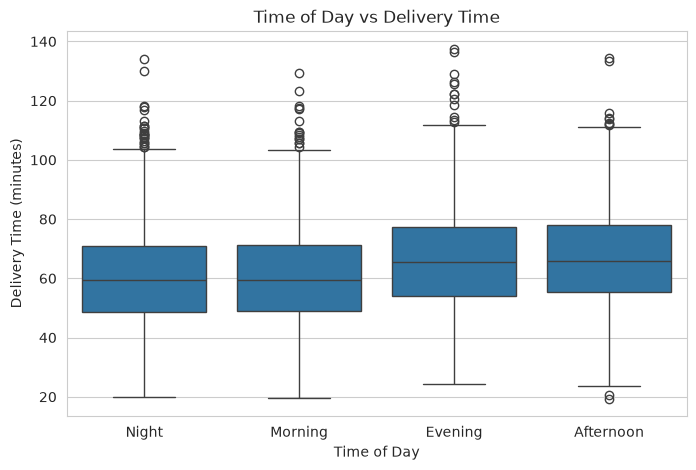

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="time_of_day",
    y="delivery_time_minutes"
)

plt.title("Time of Day vs Delivery Time")
plt.xlabel("Time of Day")
plt.ylabel("Delivery Time (minutes)")

plt.show()

In [36]:
features = [
    "order_amount",
    "number_of_items",
    "delivery_distance_km",
    "preparation_time_minutes_order",
    "preparation_time_minutes_delivery",
    "weather",
    "traffic_condition",
    "category",
    "rating",
    "hour",
    "day_of_week",
    "is_weekend",
    "time_of_day"
]

target = "delivery_time_minutes"

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['order_amount', 'number_of_items', 'delivery_distance_km', 'preparation_time_minutes_order', 'preparation_time_minutes_delivery', 'weather', 'traffic_condition', 'category', 'rating', 'hour', 'day_of_week', 'is_weekend', 'time_of_day']
Target: delivery_time_minutes
X shape: (4665, 13)
y shape: (4665,)


In [37]:
numeric_features = [
    "order_amount",
    "number_of_items",
    "delivery_distance_km",
    "preparation_time_minutes_order",
    "preparation_time_minutes_delivery",
    "rating",
    "hour",
    "day_of_week",
    "is_weekend"
]

categorical_features = [
    "weather",
    "traffic_condition",
    "category",
    "time_of_day"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['order_amount', 'number_of_items', 'delivery_distance_km', 'preparation_time_minutes_order', 'preparation_time_minutes_delivery', 'rating', 'hour', 'day_of_week', 'is_weekend']

Categorical features:
['weather', 'traffic_condition', 'category', 'time_of_day']


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (3732, 13)
Testing data : (933, 13)


In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [40]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline Linear Regression trained successfully.")

Baseline Linear Regression trained successfully.


In [41]:
y_pred_baseline = baseline_model.predict(
    X_test
)

print("Predictions generated successfully.")
print(y_pred_baseline[:10])

Predictions generated successfully.
[ 46.23128294 103.23014864  82.9630893   47.50662081  59.55727675
  72.66687119  84.3176641   54.60746381  62.4926496   66.82793576]


In [42]:
def evaluate_model(model_name, y_true, y_pred):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [43]:
baseline_results = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_baseline
)

baseline_results

{'Model': 'Linear Regression',
 'MAE': 4.910070091728267,
 'RMSE': np.float64(6.1077512792408095),
 'R2': 0.8817920616331714}

In [44]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [45]:
y_pred_rf = rf_model.predict(
    X_test
)

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [46]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

rf_results

{'Model': 'Random Forest',
 'MAE': 5.432802786709537,
 'RMSE': np.float64(6.824948395150181),
 'R2': 0.8524012429747536}

In [47]:
ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

ridge_model.fit(
    X_train,
    y_train
)

print("Ridge Regression trained successfully.")

Ridge Regression trained successfully.


In [48]:
y_pred_ridge = ridge_model.predict(
    X_test
)

ridge_results = evaluate_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
)

ridge_results

{'Model': 'Ridge Regression',
 'MAE': 4.910371358704554,
 'RMSE': np.float64(6.107936625077481),
 'R2': 0.8817848872474878}

In [49]:
lasso_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Lasso(alpha=0.01)
        )
    ]
)

lasso_model.fit(
    X_train,
    y_train
)

print("Lasso Regression trained successfully.")


Lasso Regression trained successfully.


In [50]:
y_pred_lasso = lasso_model.predict(
    X_test
)

lasso_results = evaluate_model(
    "Lasso Regression",
    y_test,
    y_pred_lasso
)

lasso_results

{'Model': 'Lasso Regression',
 'MAE': 4.914043277993341,
 'RMSE': np.float64(6.107556415148998),
 'R2': 0.8817996042176844}

In [51]:
model_comparison = pd.DataFrame([
    baseline_results,
    rf_results,
    ridge_results,
    lasso_results
])

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4.910070,6.107751,0.881792
1,Random Forest,5.432803,6.824948,0.852401
2,Ridge Regression,4.910371,6.107937,0.881785
3,Lasso Regression,4.914043,6.107556,0.881800


In [52]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 30


In [53]:
rf_importance = rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
2,num__delivery_distance_km,0.551022
13,cat__traffic_condition_High,0.109965
4,num__preparation_time_minutes_delivery,0.073194
3,num__preparation_time_minutes_order,0.071275
6,num__hour,0.030174
9,cat__weather_Clear,0.019412
14,cat__traffic_condition_Low,0.018914
0,num__order_amount,0.017835
15,cat__traffic_condition_Medium,0.017026
5,num__rating,0.013244


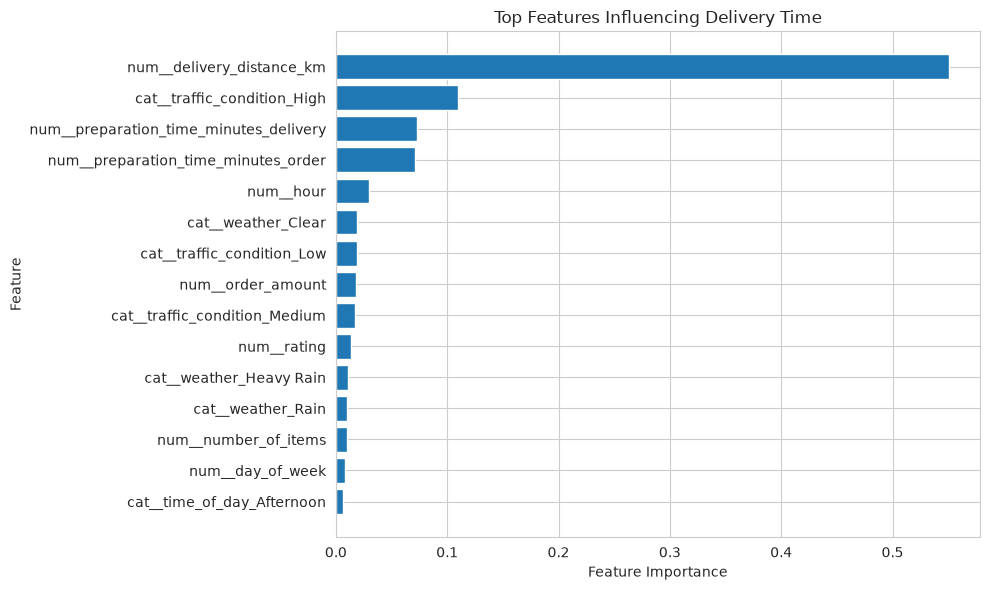

In [54]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top Features Influencing Delivery Time")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/delivery_time_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

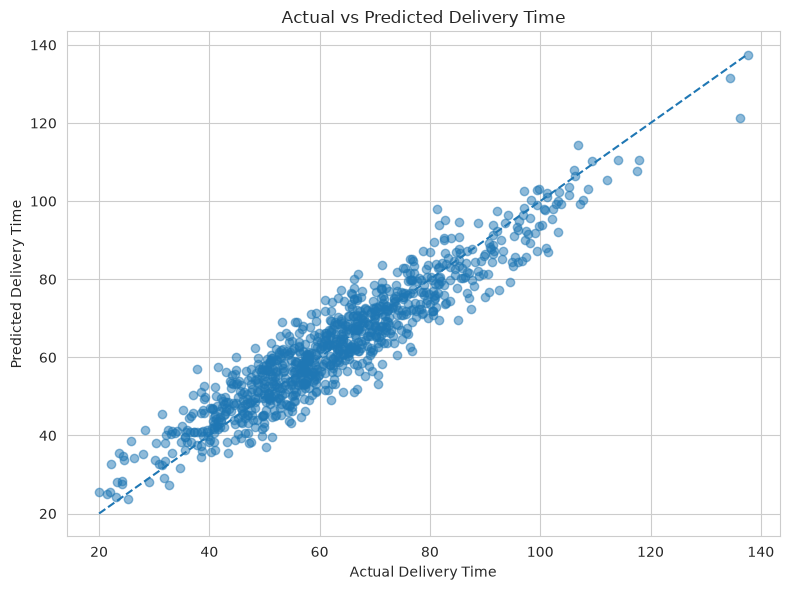

In [55]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_baseline,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/actual_vs_predicted_delivery_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

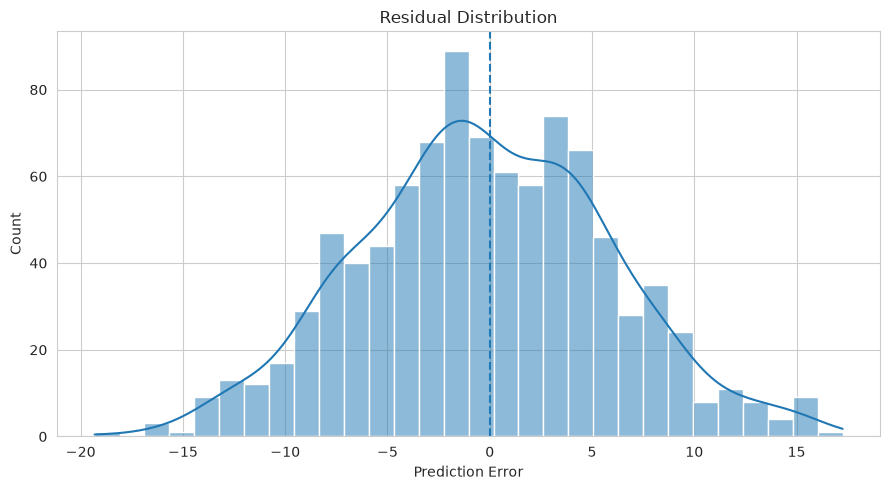

In [56]:
residuals = y_test - y_pred_baseline

plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/delivery_time_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
joblib.dump(
    baseline_model,
    "../outputs/models/delivery_time_linear_regression.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [58]:
df.to_csv(
    "../data/processed/delivery_time_features.csv",
    index=False
)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.
